In [ ]:
import subprocess, shlex, os, glob, pathlib, textwrap

R_SNIPPET = """
args <- commandArgs(trailingOnly=TRUE)
in_path  <- args[1]
out_path <- args[2]
df <- readRDS(in_path)

# write to CSV instead of parquet
library(readr)
write_csv(df, out_path)
"""

def rds_to_csv_via_rscript(in_path, out_path):
    script = textwrap.dedent(R_SNIPPET)
    cmd = f'Rscript -e {shlex.quote(script)} {shlex.quote(in_path)} {shlex.quote(out_path)}'
    subprocess.check_call(cmd, shell=True)
    print(f"✅ {in_path} → {out_path}")

DATA_DIR = "data"
for in_path in glob.glob(os.path.join(DATA_DIR, "*.rds")):
    out_path = os.path.splitext(in_path)[0] + ".csv"
    pathlib.Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    rds_to_csv_via_rscript(in_path, out_path)


✅ data/fulldata_adm1_africa.rds → data/fulldata_adm1_africa.csv
✅ data/fulldata_global.rds → data/fulldata_global.csv
✅ data/fulldata_adm0_africa.rds → data/fulldata_adm0_africa.csv


In [ ]:
import pandas as pd
import os, glob, pathlib

DATA_DIR = "data"

def csv_to_parquet(in_path, out_path):
    # Read CSV
    df = pd.read_csv(in_path)
    # Write Parquet
    df.to_parquet(out_path, index=False)
    print(f"✅ {in_path} → {out_path}")

for in_path in glob.glob(os.path.join(DATA_DIR, "*.csv")):
    out_path = os.path.splitext(in_path)[0] + ".parquet"
    pathlib.Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    csv_to_parquet(in_path, out_path)

✅ data/fulldata_global.csv → data/fulldata_global.parquet
✅ data/fulldata_adm1_africa.csv → data/fulldata_adm1_africa.parquet
✅ data/fulldata_adm0_africa.csv → data/fulldata_adm0_africa.parquet


## Country-level / Non-state Violence / Africa

In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------
# 1) Configure where your data lives
# ----------------------------
DATA_PATH = "data/fulldata_adm0_africa.parquet"  # change to your file path

# ----------------------------
# 2) Helpers to load the original full data in Python
# ----------------------------
df = pd.read_parquet(DATA_PATH)

# Ensure expected columns exist
required_base = ["country_name","gwno","year","month","yearmonth","sri_num"]
missing_base = [c for c in required_base if c not in df.columns]
if missing_base:
    raise SystemExit(f"[!] Missing required columns: {missing_base}")

# ----------------------------
# 3) Define variable groups exactly like in your R code
# ----------------------------
# Outcomes (you can switch to sbv_fat_be, osv_fat_be, nsv_fat_be if desired)
TARGET = "nsv_fat_be"

# Benchmark (BM) predictors (lagged outcomes)
bm_vars = [
    "sbv_fat_be_lag", "osv_fat_be_lag", "nsv_fat_be_lag", "sri_num_lag", "sri_fat_lag"
]

# Covariate (COV) predictors (full set from your non-log script)
cov_vars = [
    "cinc", "elev_mean", "ethfrac", "ethpol", "farmland", "forest", "irregular",
    "irst", "milex", "milper", "n_leaders", "nbuiltup", "nethgr", "newlmtnest", "npetro",
    "open_terrain", "pec", "relfrac", "relpol", "road_density", "road_length", "rugged",
    "sum_igo_anytype", "sum_igo_associate", "sum_igo_full", "sum_igo_observer",
    "tpop", "upop", "v2x_polyarchy", "wbgdp2011est", "wbgdppc2011est", "wbpopest", "xm_qudsest",
    "l1_irregular", "l1_leadertransition", "l1_n_leaders", "l1_v2x_polyarchy",
    "l1_wbgdppc2011est", "l1_wbpopest", "l1_xm_qudsest"
]

# Google Trends + Wikipedia (GTW) predictors
gtw_vars = [c for c in df.columns if (c.startswith("views") or c.startswith("hits")) and not (c.endswith("log") or c.endswith("change"))]

# Filter to keep only existing columns (robust to minor name differences)
bm_vars = [c for c in bm_vars if c in df.columns]
cov_vars = [c for c in cov_vars if c in df.columns]
gtw_vars = [c for c in gtw_vars if c in df.columns]

# Safety check: drop rows with any NA in the modeling columns we’ll use in each run
id_cols = ["country_name","gwno","year","month","yearmonth"]

# ----------------------------
# 4) Metric functions (RMSE, MAE, AC, CCC, RAC)
# ----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Lin's concordance correlation coefficient (CCC)
def ccc(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    s_x2 = y_true.var(ddof=1)
    s_y2 = y_pred.var(ddof=1)
    s_xy = np.cov(y_true, y_pred, ddof=1)[0,1]
    return (2 * s_xy) / (s_x2 + s_y2 + (mu_x - mu_y)**2 + 1e-12)

# Accuracy coefficient (AC) = Lin's accuracy component C_b (so CCC = r * AC)
def accuracy_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    s_x = y_true.std(ddof=1)
    s_y = y_pred.std(ddof=1)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    if s_x == 0 or s_y == 0:
        return 0.0
    v = (s_y / s_x) + (s_x / s_y) + ((mu_y - mu_x)**2) / (s_x * s_y)
    return 2.0 / (v + 1e-12)

# Robinson’s Agreement Coefficient (RAC).
# Here we use the widely adopted "Willmott-style" agreement denominator,
# which has been referred to as a Robinson/Agreement coefficient in forecasting work:
# RAC = 1 - sum((y - ŷ)^2) / sum((|ŷ - ȳ| + |y - ȳ|)^2)
def rac(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    ybar = y_true.mean()
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((np.abs(y_pred - ybar) + np.abs(y_true - ybar))**2) + 1e-12
    return 1 - num / den

# ----------------------------
# 5) Modeling grids akin to your mtry sequences (clamped to the feature count)
# ----------------------------
def mtry_grid(n_features, base_seq):
    # clamp each candidate to [1, n_features]
    uniq = sorted({max(1, min(n_features, int(x))) for x in base_seq})
    # also include "sqrt" and "log2" styled choices via fractions if appropriate
    if n_features >= 3:
        uniq = sorted(set(uniq + [int(np.sqrt(n_features)), max(1,int(np.log2(n_features)))]) )
    return uniq

# Sequences ported from your R code
seqs = {
    "bm":       list(range(1,6)),                  # 1..5
    "cov":      list(range(5,41,5)),               # 5..40 step 5
    "gtw":      list(range(5,21,5)),               # 5..20
    "bm_gtw":   list(range(5,26,5)),               # 5..25
    "bm_cov":   list(range(5,46,5)),               # 5..45
    "cov_gtw":  list(range(5,61,5)),               # 5..60
    "bm_cov_gtw": list(range(5,66,5)),             # 5..65
}

def build_feature_sets():
    combos = {
        "bm": bm_vars,
        "cov": cov_vars,
        "gtw": gtw_vars,
        "bm_gtw": bm_vars + gtw_vars,
        "cov_gtw": cov_vars + gtw_vars,
        "bm_cov": bm_vars + cov_vars,
        "bm_cov_gtw": bm_vars + cov_vars + gtw_vars
    }
    # drop duplicates while preserving order
    for k,v in combos.items():
        seen, dedup = set(), []
        for col in v:
            if col not in seen:
                dedup.append(col); seen.add(col)
        combos[k] = dedup
    return combos

feature_sets = build_feature_sets()

# ----------------------------
# 6) Train/Test split + model selection + metrics for each year & model
# ----------------------------
YEARS = [2020, 2021, 2022, 2023]

results = []
predictions_by_run = {}  # optional: to let you inspect per-run preds later

for heldout_year in YEARS:
    print(f"Processing {heldout_year}")
    # Train: all <= heldout_year-1; Test: == heldout_year
    train_idx = df["year"] <= (heldout_year - 1)
    test_idx  = df["year"] == heldout_year

    df_train = df.loc[train_idx].copy()
    df_test  = df.loc[test_idx].copy()

    if df_test.empty or df_train.empty:
        print(f"[!] Skipping {heldout_year}: train or test is empty.")
        continue

    for model_name, cols in feature_sets.items():
        print(f"Processing {model_name}")
        if len(cols) == 0:
            print(f"[!] Skipping {model_name}: no matching feature columns in data.")
            continue

        # drop rows with any NA in target or features (no intermediate datasets saved)
        needed = cols + [TARGET]
        df_train_clean = df_train.dropna(subset=needed)
        df_test_clean  = df_test.dropna(subset=needed)

        if df_test_clean.empty or df_train_clean.empty:
            print(f"[!] {heldout_year} / {model_name}: no rows after dropping NAs, skipping.")
            continue

        X_train = df_train_clean[cols].values
        y_train = df_train_clean[TARGET].values
        X_test  = df_test_clean[cols].values
        y_test  = df_test_clean[TARGET].values

        # Build mtry (max_features) grid per model, clamped to feature count
        nfeat = X_train.shape[1]
        grid_mtry = mtry_grid(nfeat, seqs[model_name if model_name in seqs else "bm"])

        # Define RF; tune only max_features & min_samples_leaf (analogous to min.node.size)
        param_grid = {
            "max_features": grid_mtry,
            "min_samples_leaf": [5, 10],   # mirrors your 5 & 10
            "max_depth": [None],           # keep trees deep; RF handles overfit via averaging
        }

        base = RandomForestRegressor(
            n_estimators=1000,
            n_jobs=-1,
            random_state=815,
            bootstrap=True
        )

        # 3-fold CV on the training set (shuffled=False to respect time-ish ordering)
        cv = KFold(n_splits=3, shuffle=False)
        gs = GridSearchCV(base, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1)
        gs.fit(X_train, y_train)

        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        # Metrics
        metric_rmse = rmse(y_test, y_pred)
        metric_mae  = mae(y_test, y_pred)
        metric_ccc  = ccc(y_test, y_pred)
        metric_ac   = accuracy_coefficient(y_test, y_pred)
        metric_rac  = rac(y_test, y_pred)

        res = {
            "heldout_year": heldout_year,
            "model": model_name,
            "n_features": nfeat,
            "best_max_features": best_model.get_params().get("max_features"),
            "best_min_samples_leaf": best_model.get_params().get("min_samples_leaf"),
            "RMSE": metric_rmse,
            "MAE": metric_mae,
            "AC": metric_ac,
            "CCC": metric_ccc,
            "RAC": metric_rac
        }
        results.append(res)
        print(res)

        # stash predictions (optional)
        key = (heldout_year, model_name)
        predictions_by_run[key] = pd.DataFrame({
            "country_name": df_test_clean["country_name"].values if "country_name" in df_test_clean.columns else np.nan,
            "gwno": df_test_clean["gwno"].values if "gwno" in df_test_clean.columns else np.nan,
            "year": df_test_clean["year"].values,
            "month": df_test_clean["month"].values if "month" in df_test_clean.columns else np.nan,
            "yearmonth": df_test_clean["yearmonth"].values if "yearmonth" in df_test_clean.columns else np.nan,
            "y_true": y_test,
            "y_pred": y_pred
        })

# Aggregate results into a tidy table
res_df = pd.DataFrame(results)
res_df.to_csv("results/admin0_africa_nsv.csv")

# Order columns nicely
cols_order = ["heldout_year","model","n_features","best_max_features","best_min_samples_leaf",
                "RMSE","MAE","AC","CCC","RAC"]
res_df = res_df[cols_order].sort_values(["heldout_year","model"]).reset_index(drop=True)

# Show a compact summary (rounded)
display_df = res_df.copy()
for m in ["RMSE","MAE","AC","CCC","RAC"]:
    display_df[m] = display_df[m].astype(float).round(4)

# Print the first few rows here for quick glance
display_df

Processing 2020
Processing bm
Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'heldout_year': 2020, 'model': 'bm', 'n_features': 5, 'best_max_features': 2, 'best_min_samples_leaf': 10, 'RMSE': 20.880663949336277, 'MAE': 6.231209695088592, 'AC': 0.9552900778607262, 'CCC': 0.5996327389892682, 'RAC': 0.7518967794093665}
Processing cov
Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'heldout_year': 2020, 'model': 'cov', 'n_features': 40, 'best_max_features': 5, 'best_min_samples_leaf': 10, 'RMSE': 26.9251371881647, 'MAE': 12.066448441137355, 'AC': 0.5791358681554666, 'CCC': 0.0631698099515971, 'RAC': 0.2234513166402332}
Processing gtw
Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'heldout_year': 2020, 'model': 'gtw', 'n_features': 21, 'best_max_features': 5, 'best_min_samples_leaf': 5, 'RMSE': 24.14654080519563, 'MAE': 8.930291688715776, 'AC': 0.8644624964523376, 'CCC': 0.37775177809049987, 'RAC': 0.5656363371062241}
Processing bm_gtw
Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'heldout_year': 2020, 'model': 'bm_gtw',

,heldout_year,model,n_features,best_max_features,best_min_samples_leaf,RMSE,MAE,AC,CCC,RAC
0,2020,bm,5,2,10,20.8807,6.2312,0.9553,0.5996,0.7519
1,2020,bm_cov,45,10,10,21.1937,7.7449,0.8792,0.5316,0.6993
2,2020,bm_cov_gtw,66,25,10,21.1003,6.7683,0.9383,0.5758,0.7332
3,2020,bm_gtw,26,10,10,21.4080,6.5622,0.9677,0.5948,0.7481
4,2020,cov,40,5,10,26.9251,12.0664,0.5791,0.0632,0.2235
5,2020,cov_gtw,61,15,10,27.4552,12.2862,0.6712,0.0670,0.2325
6,2020,gtw,21,5,5,24.1465,8.9303,0.8645,0.3778,0.5656
7,2021,bm,5,2,10,19.2055,6.0090,0.9325,0.6136,0.7632
8,2021,bm_cov,45,10,10,19.3718,7.2442,0.9249,0.6057,0.7583
9,2021,bm_cov_gtw,66,20,10,19.3070,6.8423,0.9461,0.6241,0.7713


Saved: figures/admin0_africa_nsv.pdf


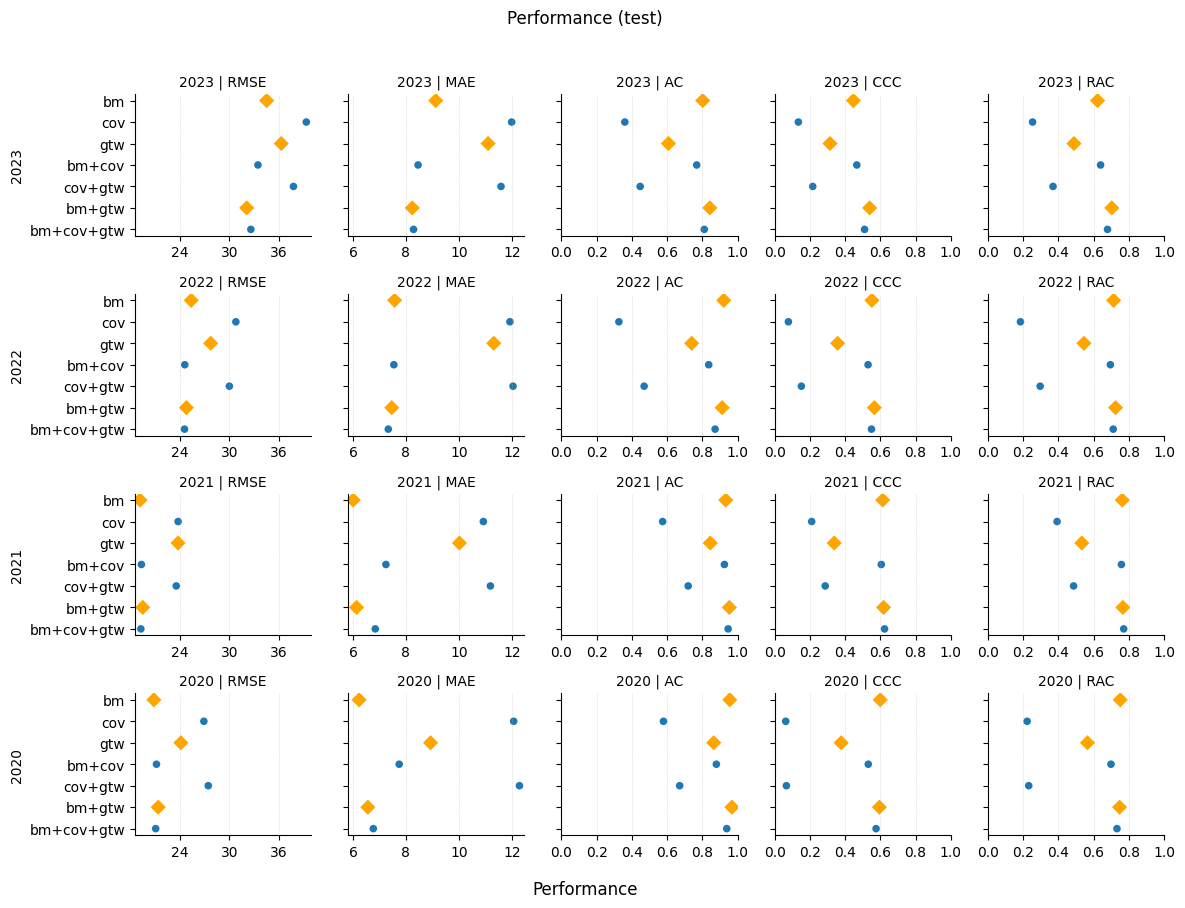

In [1]:
# --- Metrics panel per year & outcome (R-style) ------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# res_df should have these columns at minimum:
# ['heldout_year','model','RMSE','MAE','AC','CCC','RAC']
# Optionally: 'outcome' (values: 'sbv','osv','nsv','sri')

def plot_metrics_panel(res_df: pd.DataFrame,
                       outcome: str = None,
                       save_path: str = None,
                       title_prefix: str = "Performance (test)"):
    df = res_df.copy()

    if "Data" in df.columns:
        df = df[df["Data"].str.lower().eq("test")]

    if outcome is not None and "outcome" in df.columns:
        df = df[df["outcome"].str.lower().eq(outcome.lower())]

    label_map = {
        "bm_cov_gtw": "bm+cov+gtw",
        "bm_gtw":     "bm+gtw",
        "cov_gtw":    "cov+gtw",
        "bm_cov":     "bm+cov",
        "gtw":        "gtw",
        "cov":        "cov",
        "bm":         "bm",
    }
    df["model"] = df["model"].astype(str)
    df["ModelLabel"] = df["model"].map(label_map).fillna(df["model"])

    model_order = ["bm", "cov", "gtw", "bm+cov", "cov+gtw", "bm+gtw", "bm+cov+gtw"]
    metric_order = ["RMSE","MAE","AC","CCC","RAC"]

    long = df.melt(id_vars=["heldout_year","ModelLabel"],
                   value_vars=metric_order,
                   var_name="metric", value_name="value")

    # --- NEW: compute per-metric global x-lims (so each year uses the same range) ---
    fixed_ranges = {}
    for m in ["RMSE", "MAE"]:
        vals = long.loc[long["metric"].eq(m), "value"].dropna().astype(float)
        if not vals.empty and np.isfinite(vals.min()) and np.isfinite(vals.max()):
            lo, hi = float(vals.min()), float(vals.max())
            pad = 0.03 * (hi - lo if hi > lo else (hi if hi > 0 else 1.0))
            fixed_ranges[m] = (max(0.0, lo - pad), hi + pad)

    year_order = sorted(long["heldout_year"].unique(), reverse=True)

    g = sns.FacetGrid(long,
                      row="heldout_year", row_order=year_order,
                      col="metric", col_order=metric_order,
                      margin_titles=False, sharex=False, sharey=True,
                      height=2.2, aspect=1.1)

    def _base_scatter(data, color, **kwargs):
        ax = plt.gca()
        data = data.copy()
        data["ModelLabel"] = pd.Categorical(data["ModelLabel"],
                                            categories=model_order, ordered=True)
        sns.scatterplot(data=data, x="value", y="ModelLabel",
                        s=30, marker="o", color=color, edgecolor="none", ax=ax)

        hl = data[data["ModelLabel"].isin(["bm","gtw","bm+gtw"])]
        if not hl.empty:
            sns.scatterplot(data=hl, x="value", y="ModelLabel",
                            s=60, marker="D", color="orange", edgecolor="none", ax=ax)

        metric = data["metric"].iloc[0]
        if metric in ("AC","CCC","RAC"):
            ax.set_xlim(0, 1)
            ax.set_xticks(np.linspace(0, 1, 6))
        else:
            # Use the same xmin/xmax for all years within RMSE/MAE columns
            if metric in fixed_ranges:
                ax.set_xlim(*fixed_ranges[metric])
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))

        ax.set_ylabel(None)
        ax.set_xlabel(None)

    g.map_dataframe(_base_scatter, color="tab:blue")

    for ax in g.axes.flat:
        ax.grid(True, axis="x", linestyle=":", linewidth=0.5, alpha=0.7)

    for r, year in enumerate(year_order):
        ax = g.axes[r, 0]
        ax.set_ylabel(f"{year}")

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.figure.supxlabel("Performance")
    g.figure.supylabel(None)

    suffix = f" • outcome: {outcome.upper()}" if (outcome and 'outcome' in df.columns) else ""
    g.figure.suptitle(f"{title_prefix}{suffix}", y=1.02, fontsize=12)

    plt.tight_layout()
    if save_path:
        g.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    return g


# --- Example usage -----------------------------------------------------------
# 1) If your res_df already contains only TEST metrics for SRI:
res_df = pd.read_csv("results/admin0_africa_nsv.csv")
plot_metrics_panel(res_df, outcome=None, save_path="figures/admin0_africa_nsv.pdf")


## Country-level / Security-related / Africa

In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------
# 1) Configure where your data lives
# ----------------------------
DATA_PATH = "data/fulldata_adm0_africa.parquet"  # change to your file path

# ----------------------------
# 2) Helpers to load the original full data in Python
# ----------------------------
df = pd.read_parquet(DATA_PATH)

# Ensure expected columns exist
required_base = ["country_name","gwno","year","month","yearmonth","sri_num"]
missing_base = [c for c in required_base if c not in df.columns]
if missing_base:
    raise SystemExit(f"[!] Missing required columns: {missing_base}")

# ----------------------------
# 3) Define variable groups exactly like in your R code
# ----------------------------
# Outcomes (you can switch to sbv_fat_be, osv_fat_be, nsv_fat_be if desired)
TARGET = "sri_num"

# Benchmark (BM) predictors (lagged outcomes)
bm_vars = [
    "sbv_fat_be_lag", "osv_fat_be_lag", "nsv_fat_be_lag", "sri_num_lag", "sri_fat_lag"
]

# Covariate (COV) predictors (full set from your non-log script)
cov_vars = [
    "cinc", "elev_mean", "ethfrac", "ethpol", "farmland", "forest", "irregular",
    "irst", "milex", "milper", "n_leaders", "nbuiltup", "nethgr", "newlmtnest", "npetro",
    "open_terrain", "pec", "relfrac", "relpol", "road_density", "road_length", "rugged",
    "sum_igo_anytype", "sum_igo_associate", "sum_igo_full", "sum_igo_observer",
    "tpop", "upop", "v2x_polyarchy", "wbgdp2011est", "wbgdppc2011est", "wbpopest", "xm_qudsest",
    "l1_irregular", "l1_leadertransition", "l1_n_leaders", "l1_v2x_polyarchy",
    "l1_wbgdppc2011est", "l1_wbpopest", "l1_xm_qudsest"
]

# Google Trends + Wikipedia (GTW) predictors
gtw_vars = [c for c in df.columns if (c.startswith("views") or c.startswith("hits")) and not (c.endswith("log") or c.endswith("change"))]

# Filter to keep only existing columns (robust to minor name differences)
bm_vars = [c for c in bm_vars if c in df.columns]
cov_vars = [c for c in cov_vars if c in df.columns]
gtw_vars = [c for c in gtw_vars if c in df.columns]

# Safety check: drop rows with any NA in the modeling columns we’ll use in each run
id_cols = ["country_name","gwno","year","month","yearmonth"]

# ----------------------------
# 4) Metric functions (RMSE, MAE, AC, CCC, RAC)
# ----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Lin's concordance correlation coefficient (CCC)
def ccc(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    s_x2 = y_true.var(ddof=1)
    s_y2 = y_pred.var(ddof=1)
    s_xy = np.cov(y_true, y_pred, ddof=1)[0,1]
    return (2 * s_xy) / (s_x2 + s_y2 + (mu_x - mu_y)**2 + 1e-12)

# Accuracy coefficient (AC) = Lin's accuracy component C_b (so CCC = r * AC)
def accuracy_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    s_x = y_true.std(ddof=1)
    s_y = y_pred.std(ddof=1)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    if s_x == 0 or s_y == 0:
        return 0.0
    v = (s_y / s_x) + (s_x / s_y) + ((mu_y - mu_x)**2) / (s_x * s_y)
    return 2.0 / (v + 1e-12)

# Robinson’s Agreement Coefficient (RAC).
# Here we use the widely adopted "Willmott-style" agreement denominator,
# which has been referred to as a Robinson/Agreement coefficient in forecasting work:
# RAC = 1 - sum((y - ŷ)^2) / sum((|ŷ - ȳ| + |y - ȳ|)^2)
def rac(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    ybar = y_true.mean()
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((np.abs(y_pred - ybar) + np.abs(y_true - ybar))**2) + 1e-12
    return 1 - num / den

# ----------------------------
# 5) Modeling grids akin to your mtry sequences (clamped to the feature count)
# ----------------------------
def mtry_grid(n_features, base_seq):
    # clamp each candidate to [1, n_features]
    uniq = sorted({max(1, min(n_features, int(x))) for x in base_seq})
    # also include "sqrt" and "log2" styled choices via fractions if appropriate
    if n_features >= 3:
        uniq = sorted(set(uniq + [int(np.sqrt(n_features)), max(1,int(np.log2(n_features)))]) )
    return uniq

# Sequences ported from your R code
seqs = {
    "bm":       list(range(1,6)),                  # 1..5
    "cov":      list(range(5,41,5)),               # 5..40 step 5
    "gtw":      list(range(5,21,5)),               # 5..20
    "bm_gtw":   list(range(5,26,5)),               # 5..25
    "bm_cov":   list(range(5,46,5)),               # 5..45
    "cov_gtw":  list(range(5,61,5)),               # 5..60
    "bm_cov_gtw": list(range(5,66,5)),             # 5..65
}

def build_feature_sets():
    combos = {
        "bm": bm_vars,
        "cov": cov_vars,
        "gtw": gtw_vars,
        "bm_gtw": bm_vars + gtw_vars,
        "cov_gtw": cov_vars + gtw_vars,
        "bm_cov": bm_vars + cov_vars,
        "bm_cov_gtw": bm_vars + cov_vars + gtw_vars
    }
    # drop duplicates while preserving order
    for k,v in combos.items():
        seen, dedup = set(), []
        for col in v:
            if col not in seen:
                dedup.append(col); seen.add(col)
        combos[k] = dedup
    return combos

feature_sets = build_feature_sets()

# ----------------------------
# 6) Train/Test split + model selection + metrics for each year & model
# ----------------------------
YEARS = [2020, 2021, 2022, 2023]

results = []
predictions_by_run = {}  # optional: to let you inspect per-run preds later

for heldout_year in YEARS:
    print(f"Processing {heldout_year}")
    # Train: all <= heldout_year-1; Test: == heldout_year
    train_idx = df["year"] <= (heldout_year - 1)
    test_idx  = df["year"] == heldout_year

    df_train = df.loc[train_idx].copy()
    df_test  = df.loc[test_idx].copy()

    if df_test.empty or df_train.empty:
        print(f"[!] Skipping {heldout_year}: train or test is empty.")
        continue

    for model_name, cols in feature_sets.items():
        print(f"Processing {model_name}")
        if len(cols) == 0:
            print(f"[!] Skipping {model_name}: no matching feature columns in data.")
            continue

        # drop rows with any NA in target or features (no intermediate datasets saved)
        needed = cols + [TARGET]
        df_train_clean = df_train.dropna(subset=needed)
        df_test_clean  = df_test.dropna(subset=needed)

        if df_test_clean.empty or df_train_clean.empty:
            print(f"[!] {heldout_year} / {model_name}: no rows after dropping NAs, skipping.")
            continue

        X_train = df_train_clean[cols].values
        y_train = df_train_clean[TARGET].values
        X_test  = df_test_clean[cols].values
        y_test  = df_test_clean[TARGET].values

        # Build mtry (max_features) grid per model, clamped to feature count
        nfeat = X_train.shape[1]
        grid_mtry = mtry_grid(nfeat, seqs[model_name if model_name in seqs else "bm"])

        # Define RF; tune only max_features & min_samples_leaf (analogous to min.node.size)
        param_grid = {
            "max_features": grid_mtry,
            "min_samples_leaf": [5, 10],   # mirrors your 5 & 10
            "max_depth": [None],           # keep trees deep; RF handles overfit via averaging
        }

        base = RandomForestRegressor(
            n_estimators=1000,
            n_jobs=-1,
            random_state=815,
            bootstrap=True
        )

        # 3-fold CV on the training set (shuffled=False to respect time-ish ordering)
        cv = KFold(n_splits=3, shuffle=False)
        gs = GridSearchCV(base, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1)
        gs.fit(X_train, y_train)

        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        # Metrics
        metric_rmse = rmse(y_test, y_pred)
        metric_mae  = mae(y_test, y_pred)
        metric_ccc  = ccc(y_test, y_pred)
        metric_ac   = accuracy_coefficient(y_test, y_pred)
        metric_rac  = rac(y_test, y_pred)

        res = {
            "heldout_year": heldout_year,
            "model": model_name,
            "n_features": nfeat,
            "best_max_features": best_model.get_params().get("max_features"),
            "best_min_samples_leaf": best_model.get_params().get("min_samples_leaf"),
            "RMSE": metric_rmse,
            "MAE": metric_mae,
            "AC": metric_ac,
            "CCC": metric_ccc,
            "RAC": metric_rac
        }
        results.append(res)
        print(res)

        # stash predictions (optional)
        key = (heldout_year, model_name)
        predictions_by_run[key] = pd.DataFrame({
            "country_name": df_test_clean["country_name"].values if "country_name" in df_test_clean.columns else np.nan,
            "gwno": df_test_clean["gwno"].values if "gwno" in df_test_clean.columns else np.nan,
            "year": df_test_clean["year"].values,
            "month": df_test_clean["month"].values if "month" in df_test_clean.columns else np.nan,
            "yearmonth": df_test_clean["yearmonth"].values if "yearmonth" in df_test_clean.columns else np.nan,
            "y_true": y_test,
            "y_pred": y_pred
        })

# Aggregate results into a tidy table
res_df = pd.DataFrame(results)
res_df.to_csv("results/admin0_africa_nsv.csv")

# Order columns nicely
cols_order = ["heldout_year","model","n_features","best_max_features","best_min_samples_leaf",
                "RMSE","MAE","AC","CCC","RAC"]
res_df = res_df[cols_order].sort_values(["heldout_year","model"]).reset_index(drop=True)

# Show a compact summary (rounded)
display_df = res_df.copy()
for m in ["RMSE","MAE","AC","CCC","RAC"]:
    display_df[m] = display_df[m].astype(float).round(4)

# Print the first few rows here for quick glance
display_df

Saved: figures/admin0_africa_sri.pdf


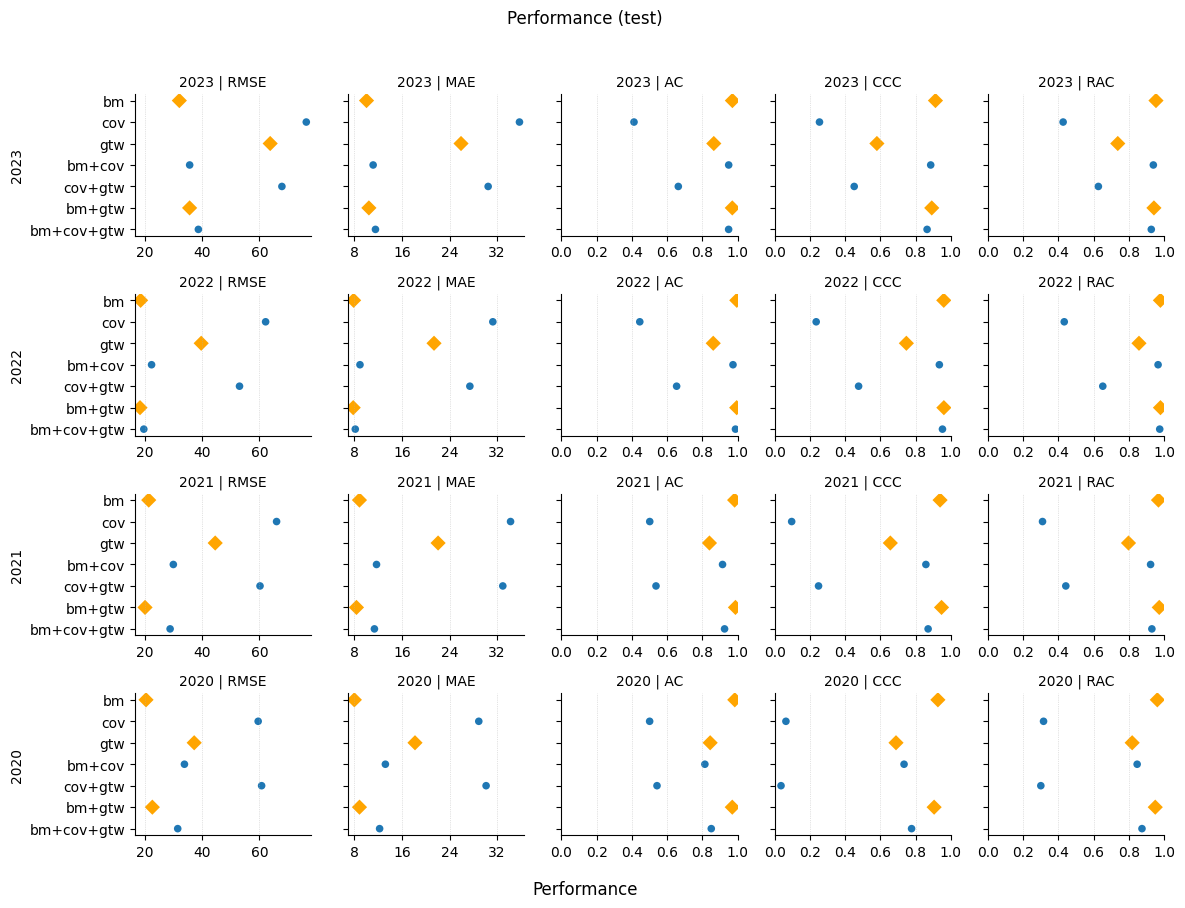

In [2]:
res_df = pd.read_csv("results/admin0_africa_sri.csv")
plot_metrics_panel(res_df, outcome=None, save_path="figures/admin0_africa_sri.pdf")

## Province-level / Non-state Violence / Africa

In [1]:
# ===== ADM1 Africa: RF forecasting (bm / cov / gtw and combos), held-outs 2020-2023 =====
# No intermediate datasets—everything is sliced straight from the full source table.

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------------------------------------------------------------------
# 0) CONFIG
# ----------------------------------------------------------------------------------------
# Path to your full ADM1 Africa dataframe
# Supported: .parquet, .feather, .csv; .rds if pyreadr is available.
DATA_PATH = Path("data/fulldata_adm1_africa.parquet")  # change to your file

# Outcome to predict (switch as needed): 'sri_num', 'nsv_fat_be', 'sbv_fat_be', 'osv_fat_be'
TARGET = "nsv_fat_be"

# Held-out test years
YEARS = [2020, 2021, 2022, 2023]

In [2]:
# ==== GPU/CPU backend switch ======================================
BACKEND = "gpu_rf"   # options: "cpu_rf", "gpu_rf", "gpu_xgb"

# Try importing GPU libs if requested
cuml_ok, xgb_ok = False, False
if BACKEND == "gpu_rf":
    try:
        from cuml.ensemble import RandomForestRegressor as cuRF
        cuml_ok = True
    except Exception as e:
        print(f"[gpu_rf] cuML not available: {e}. Falling back to CPU.")
        BACKEND = "cpu_rf"

if BACKEND == "gpu_xgb":
    try:
        import xgboost as xgb
        xgb_ok = True
    except Exception as e:
        print(f"[gpu_xgb] XGBoost not available: {e}. Falling back to CPU.")
        BACKEND = "cpu_rf"
# ================================================================


def _fit_predict_gpu_rf(X_tr, y_tr, X_te, param):
    """
    Fit a cuML RandomForestRegressor with given params, return preds.
    - Use max_depth=0 (unlimited) instead of None (cuML requires int)
    - Convert max_features int -> fraction if desired (safer for cuML)
    """
    from cuml.ensemble import RandomForestRegressor as cuRF

    # Use float32 on GPU for speed
    X_tr32 = X_tr.astype(np.float32, copy=False)
    X_te32 = X_te.astype(np.float32, copy=False)
    y_tr32 = y_tr.astype(np.float32, copy=False)

    nfeat = X_tr32.shape[1]
    mtry = int(param["max_features"])
    # cuML accepts either int or fraction; fraction is robust:
    max_features = max(1, min(nfeat, mtry))
    max_features_frac = float(max_features) / float(nfeat)

    model = cuRF(
        n_estimators=1000,
        # Use fraction to be explicit for cuML
        max_features=max_features_frac,      # fraction in (0,1]
        min_samples_leaf=int(param["min_samples_leaf"]),
        max_depth=32,                         # 0 == unlimited depth in cuML
        bootstrap=True,
        random_state=815,
        n_streams=32,
    )
    model.fit(X_tr32, y_tr32)
    preds = model.predict(X_te32).astype(np.float64)  # back to float64 for metrics
    return preds


def _fit_predict_gpu_xgb(X_tr, y_tr, X_te, param):
    """
    Fit GPU XGBoost; we emulate your grid by mapping:
      - max_features -> colsample_bytree
      - min_samples_leaf -> min_child_weight (not identical, but similar regularization)
    """
    # DMatrix with float32
    dtr = xgb.DMatrix(X_tr.astype(np.float32, copy=False), label=y_tr.astype(np.float32, copy=False))
    dte = xgb.DMatrix(X_te.astype(np.float32, copy=False))

    # Derive colsample by relative fraction of features
    nfeat = X_tr.shape[1]
    colsample = min(1.0, max(0.05, float(param["max_features"]) / max(1, nfeat)))

    params = {
        "tree_method": "gpu_hist",
        "device": "cuda",
        "max_depth": 0,            # let XGB choose splits; behaves like deep trees
        "eta": 0.2,                # modest learning rate to converge quickly
        "subsample": 0.9,
        "colsample_bytree": colsample,
        "min_child_weight": float(param["min_samples_leaf"]),  # not the same, but a stabilizer
        "objective": "reg:squarederror",
        "seed": 815,
        "nthread": -1,
    }
    bst = xgb.train(params, dtr, num_boost_round=600, verbose_eval=False)
    preds = bst.predict(dte).astype(np.float64)
    return preds


def _fit_predict_cpu_rf(X_tr, y_tr, X_te, param):
    """
    Plain sklearn RF (your original). We keep it for fallback and parity checks.
    """
    model = RandomForestRegressor(
        n_estimators=1000,
        max_features=param["max_features"],
        min_samples_leaf=param["min_samples_leaf"],
        max_depth=None,
        bootstrap=True,
        random_state=815,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return preds


def _gpu_or_cpu_fit_predict(X_tr, y_tr, X_te, param):
    if BACKEND == "gpu_rf":
        return _fit_predict_gpu_rf(X_tr, y_tr, X_te, param)
    elif BACKEND == "gpu_xgb":
        return _fit_predict_gpu_xgb(X_tr, y_tr, X_te, param)
    else:
        return _fit_predict_cpu_rf(X_tr, y_tr, X_te, param)


def fit_eval_year(df_full: pd.DataFrame, heldout_year: int, model_key: str, features: list):
    # Training: year ≤ heldout_year-1; Testing: year == heldout_year
    df_tr = df_full[df_full["year"] <= (heldout_year - 1)]
    df_te = df_full[df_full["year"] == heldout_year]
    if df_tr.empty or df_te.empty:
        return None

    cols_needed = features + [TARGET]
    df_tr = df_tr.dropna(subset=cols_needed)
    df_te = df_te.dropna(subset=cols_needed)
    if df_tr.empty or df_te.empty:
        return None

    X_tr = df_tr[features].to_numpy()
    y_tr = df_tr[TARGET].to_numpy()
    X_te = df_te[features].to_numpy()
    y_te = df_te[TARGET].to_numpy()

    # ---- Manual KFold grid search (fast, no sklearn overhead on CPU) ----
    nfeat = X_tr.shape[1]
    grid_mtry = mtry_grid(nfeat, model_key)
    leaf_grid = [5, 10]

    best_score = np.inf
    best_param = None
    # simple 3-fold, no shuffle (time-ish)
    kf = KFold(n_splits=3, shuffle=False)

    # Downcast once for GPU (we’ll still pass float64 to metrics later)
    X_tr_base = X_tr
    y_tr_base = y_tr

    for mtry in grid_mtry:
        for leaf in leaf_grid:
            fold_mse = []
            for tr_idx, va_idx in kf.split(X_tr_base):
                X_tr_fold = X_tr_base[tr_idx]
                y_tr_fold = y_tr_base[tr_idx]
                X_va_fold = X_tr_base[va_idx]
                y_va_fold = y_tr_base[va_idx]

                preds_va = _gpu_or_cpu_fit_predict(
                    X_tr_fold, y_tr_fold, X_va_fold,
                    {"max_features": mtry, "min_samples_leaf": leaf}
                )
                fold_mse.append(mean_squared_error(y_va_fold, preds_va))

            mean_mse = float(np.mean(fold_mse))
            if mean_mse < best_score:
                best_score = mean_mse
                best_param = {"max_features": mtry, "min_samples_leaf": leaf}

    # Fit best on full train, predict test
    y_hat = _gpu_or_cpu_fit_predict(X_tr, y_tr, X_te, best_param)

    out = {
        "heldout_year": heldout_year,
        "model": model_key,
        "n_features": nfeat,
        "best_max_features": best_param["max_features"],
        "best_min_samples_leaf": best_param["min_samples_leaf"],
        "RMSE": rmse(y_te, y_hat),
        "MAE": mae(y_te, y_hat),
        "AC": accuracy_coefficient(y_te, y_hat),
        "CCC": ccc(y_te, y_hat),
        "RAC": rac(y_te, y_hat),
    }
    return out


In [ ]:
# ----------------------------------------------------------------------------------------
# 1) Load the full ADM1 data without creating derived tables
# ----------------------------------------------------------------------------------------
df = pd.read_parquet(DATA_PATH).copy()

# Required ID/time columns (as per your ADM1 R code)
needed = ["gadmname", "isocode2full", "year", "month"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise SystemExit(f"Missing required ADM1 columns: {missing}")

if TARGET not in df.columns:
    raise SystemExit(f"Target column '{TARGET}' not found.")

# ----------------------------------------------------------------------------------------
# 2) Define variable groups exactly like your ADM1 R script
# ----------------------------------------------------------------------------------------
# BM: lagged outcomes
bm_vars = ["sbv_fat_be_lag", "osv_fat_be_lag", "nsv_fat_be_lag", "sri_num_lag", "sri_fat_lag"]

# COV: ADM1 set (province-level covariates)
cov_vars = [
    "elev_mean", "farmland", "forest", "gdp_ppp", "nbuiltup", "nethgr", "nl", "npetro",
    "open_terrain", "pop_sum", "rain", "road_density", "road_length", "temp"
]

# GTW: startswith 'views' or 'hits', excluding *log / *change
gtw_vars = [c for c in df.columns
            if (c.startswith("views") or c.startswith("hits"))
            and not (c.endswith("log") or c.endswith("change"))]

# Keep only those that exist (robust to minor schema variance)
bm_vars  = [c for c in bm_vars  if c in df.columns]
cov_vars = [c for c in cov_vars if c in df.columns]
gtw_vars = [c for c in gtw_vars if c in df.columns]

def build_feature_sets():
    combos = {
        "bm": bm_vars,
        "cov": cov_vars,
        "gtw": gtw_vars,
        "bm_gtw": bm_vars + gtw_vars,
        "cov_gtw": cov_vars + gtw_vars,
        "bm_cov": bm_vars + cov_vars,
        "bm_cov_gtw": bm_vars + cov_vars + gtw_vars,
    }
    # deduplicate while preserving order
    out = {}
    for k, cols in combos.items():
        seen, dedup = set(), []
        for c in cols:
            if c not in seen:
                dedup.append(c); seen.add(c)
        out[k] = dedup
    return out

FEATURE_SETS = build_feature_sets()

# ----------------------------------------------------------------------------------------
# 3) Metrics (RMSE, MAE, AC, CCC, RAC)
# ----------------------------------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    s_x2 = y_true.var(ddof=1)
    s_y2 = y_pred.var(ddof=1)
    s_xy = np.cov(y_true, y_pred, ddof=1)[0, 1]
    return float((2 * s_xy) / (s_x2 + s_y2 + (mu_x - mu_y)**2 + 1e-12))

def accuracy_coefficient(y_true, y_pred):
    # Lin's accuracy component C_b, so CCC = r * C_b
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    s_x = y_true.std(ddof=1)
    s_y = y_pred.std(ddof=1)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    if s_x == 0 or s_y == 0:
        return 0.0
    v = (s_y / s_x) + (s_x / s_y) + ((mu_y - mu_x) ** 2) / (s_x * s_y)
    return float(2.0 / (v + 1e-12))

def rac(y_true, y_pred):
    # Willmott-style agreement coefficient (used as RAC in your pipeline)
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ybar = y_true.mean()
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((np.abs(y_pred - ybar) + np.abs(y_true - ybar)) ** 2) + 1e-12
    return float(1 - num / den)

# ----------------------------------------------------------------------------------------
# 4) ADM1 mtry sequences (mirroring your R grids)
# ----------------------------------------------------------------------------------------
# Note: these are *upper bounds* that will be clamped ≤ n_features for each model.
ADM1_MTRY_SEQ = {
    "bm":          list(range(1, 6)),            # 1..5
    "cov":         list(range(2, 15, 2)),        # 2..14 step 2
    "gtw":         list(range(5, 21, 5)),        # 5..20
    "bm_gtw":      list(range(5, 26, 5)),        # 5..25
    "bm_cov":      list(range(5, 21, 5)),        # 5..20
    "cov_gtw":     list(range(5, 36, 5)),        # 5..35
    "bm_cov_gtw":  list(range(5, 41, 5)),        # 5..40
}

def mtry_grid(n_features: int, model_key: str):
    base = ADM1_MTRY_SEQ.get(model_key, [1, 2, 3, 4, 5])
    clamped = sorted({max(1, min(n_features, int(x))) for x in base})
    # add sqrt/log2 variants for good measure
    if n_features >= 3:
        clamped.extend([int(np.sqrt(n_features)), max(1, int(np.log2(n_features)))])
    return sorted(set(clamped))

all_results = []
for yr in YEARS:
    print(f"Processing {yr}")
    for mkey, feats in FEATURE_SETS.items():
        print(f"Processing {mkey}")
        if len(feats) == 0:
            continue
        res = fit_eval_year(df, yr, mkey, feats)
        if res is not None:
            all_results.append(res)

results_df = pd.DataFrame(all_results)
if results_df.empty:
    print("No results produced—check data availability, NA filtering, and TARGET column.")
else:
    cols = ["heldout_year","model","n_features","best_max_features","best_min_samples_leaf",
            "RMSE","MAE","AC","CCC","RAC"]
    results_df = results_df[cols].sort_values(["heldout_year","model"]).reset_index(drop=True)

res_df = results_df

res_df

Processing 2020
Processing bm
Processing cov
Processing gtw
Processing bm_gtw
Processing cov_gtw
